# Bài 1: Titanic Dataset – Logistic Regression vs Linear Regression

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 2. Đọc dữ liệu

Dùng bộ Titanic chuẩn (891 hành khách) qua `seaborn.load_dataset("titanic")`. Nếu bạn có file CSV riêng từ bài tập trước, thay dòng bên dưới bằng `pd.read_csv("titanic.csv")`.

In [2]:
df = sns.load_dataset("titanic")

print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## 3. Khám phá dữ liệu (EDA)

### 3.1. Phân bố target và các yếu tố liên quan tới sống sót

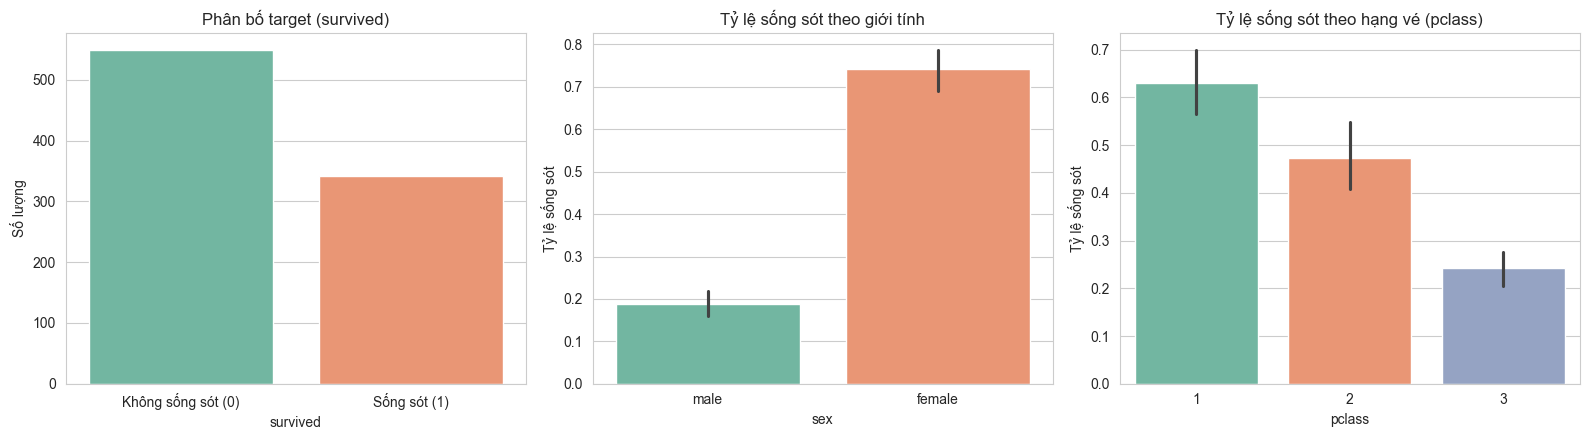

Tỷ lệ sống sót tổng thể: 0.3838


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=df, x="survived", ax=axes[0], hue="survived", legend=False, palette="Set2")
axes[0].set_title("Phân bố target (survived)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Không sống sót (0)", "Sống sót (1)"])
axes[0].set_ylabel("Số lượng")

sns.barplot(data=df, x="sex", y="survived", ax=axes[1], hue="sex", legend=False, palette="Set2")
axes[1].set_title("Tỷ lệ sống sót theo giới tính")
axes[1].set_ylabel("Tỷ lệ sống sót")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[2], hue="pclass", legend=False, palette="Set2")
axes[2].set_title("Tỷ lệ sống sót theo hạng vé (pclass)")
axes[2].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()

print("Tỷ lệ sống sót tổng thể:", round(df["survived"].mean(), 4))

**Nhận xét:** Target hơi mất cân bằng (~38% sống sót, ~62% không) nhưng không quá nghiêm trọng, không cần xử lý đặc biệt (như oversampling), chỉ cần `stratify` khi chia train/test là đủ. Hai yếu tố ảnh hưởng rõ rệt nhất tới sống sót là **giới tính** (nữ sống sót nhiều hơn hẳn nam — phù hợp với chính sách "phụ nữ và trẻ em trước") và **hạng vé** (hạng 1 sống sót nhiều hơn hạng 3 — phản ánh vị trí cabin gần xuồng cứu sinh hơn).

### 3.2. Kiểm tra missing values

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_percent
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


**Nhận xét:** `deck` mất tới **77%** dữ liệu — quá nhiều để impute một cách đáng tin cậy, nên sẽ **loại bỏ cột này** thay vì cố gắng điền giá trị. `age` mất ~20%, đủ ít để impute bằng **median** (cách phổ biến và an toàn cho Titanic, tránh bị ảnh hưởng bởi outlier tuổi). `embarked` chỉ mất 2 dòng — loại thẳng 2 dòng đó vì không đáng kể.

### 3.3. Các cột dư thừa / trùng thông tin

Dataset của seaborn có sẵn một số cột **phái sinh từ chính các cột khác**, nếu giữ lại sẽ gây trùng lặp thông tin không cần thiết (không phải leakage nghiêm trọng vì đều tính từ feature, nhưng làm mô hình học thông tin dư thừa):

- `class` — trùng hoàn toàn với `pclass` (chỉ khác dạng chữ/số)
- `alive` — trùng hoàn toàn với `survived` (chính là **target dạng chữ**, nếu giữ lại sẽ bị data leakage tuyệt đối)
- `embark_town` — trùng hoàn toàn với `embarked` (chỉ khác dạng viết tắt/đầy đủ)
- `who`, `adult_male` — suy ra trực tiếp từ `age` và `sex`
- `alone` — suy ra trực tiếp từ `sibsp` + `parch`

→ Loại bỏ toàn bộ các cột này, chỉ giữ lại các cột **gốc, độc lập về mặt thông tin**.

In [6]:
drop_cols = ["deck", "class", "alive", "embark_town", "who", "adult_male", "alone"]
df = df.drop(columns=drop_cols)

print("Shape sau khi loại cột dư thừa:", df.shape)
print("Các cột còn lại:", df.columns.tolist())

Shape sau khi loại cột dư thừa: (891, 8)
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


## 4. Tiền xử lý dữ liệu

### 4.1. Xử lý missing values

In [7]:
# age: impute bằng median
df["age"] = df["age"].fillna(df["age"].median())

# embarked: chỉ mất 2 dòng, loại bỏ trực tiếp
df = df.dropna(subset=["embarked"]).reset_index(drop=True)

print("Missing values còn lại:", df.isna().sum().sum())
print("Shape sau khi xử lý missing:", df.shape)

Missing values còn lại: 0
Shape sau khi xử lý missing: (889, 8)


### 4.2. Kiểm tra trùng lặp (duplicate)

Với dataset Titanic (chỉ giữ các đặc trưng nhân khẩu học, không có `name`/`ticket`/`passengerid`), việc **nhiều hành khách khác nhau có cùng `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`** là hoàn toàn hợp lý về mặt thống kê (ví dụ: nhiều nam giới 25 tuổi đi vé hạng 2, không đi cùng gia đình, khởi hành từ Southampton). Đây **không phải lỗi nhập liệu**, nên khác với Bài 2, ở đây ta **không** dùng `drop_duplicates()` — làm vậy sẽ xóa nhầm các hành khách thật, làm méo phân phối lớp.

In [8]:
print("Số dòng trùng hoàn toàn (chỉ để tham khảo, KHÔNG xóa):", df.duplicated().sum())
print("→ Giữ nguyên, vì đây là trùng ngẫu nhiên giữa các hành khách khác nhau, không phải lỗi dữ liệu.")

Số dòng trùng hoàn toàn (chỉ để tham khảo, KHÔNG xóa): 116
→ Giữ nguyên, vì đây là trùng ngẫu nhiên giữa các hành khách khác nhau, không phải lỗi dữ liệu.


### 4.3. Encode biến phân loại

In [9]:
# sex: binary encode
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# embarked: one-hot encode (3 giá trị: C, Q, S -> drop_first để tránh multicollinearity)
df = pd.get_dummies(df, columns=["embarked"], drop_first=True)

print("Các cột sau khi encode:", df.columns.tolist())
df.head()

Các cột sau khi encode: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


## 5. Chia train/test và chuẩn hóa dữ liệu

Chia theo tỷ lệ **80/20** với `stratify=y` (giữ nguyên tỷ lệ sống sót giữa train/test), `random_state=42` — cùng chuẩn đã dùng khi chia dữ liệu Dry Bean ở Bài 2, đảm bảo phương pháp chia dữ liệu nhất quán giữa 2 bài tập.

In [10]:
target = "survived"
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Tỷ lệ sống sót - Train:", round(y_train.mean(), 4))
print("Tỷ lệ sống sót - Test :", round(y_test.mean(), 4))

Train shape: (711, 8) | Test shape: (178, 8)
Tỷ lệ sống sót - Train: 0.3826
Tỷ lệ sống sót - Test : 0.382


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã scale xong. Mean train ~ 0:", np.round(X_train_scaled.mean(), 4), "| Std train ~ 1:", np.round(X_train_scaled.std(), 4))

Đã scale xong. Mean train ~ 0: -0.0 | Std train ~ 1: 1.0


## 6. Mô hình: Logistic Regression

Đây là bài toán **phân loại nhị phân** (sống sót / không sống sót), phù hợp trực tiếp với Logistic Regression — mô hình dùng hàm **sigmoid** để đưa output về khoảng [0, 1], diễn giải như xác suất sống sót, rồi threshold ở 0.5 để ra quyết định lớp.

In [12]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print("Đã train xong Logistic Regression.")
print("Ví dụ 5 xác suất dự đoán đầu tiên:", np.round(y_proba_logreg[:5], 4))

Đã train xong Logistic Regression.
Ví dụ 5 xác suất dự đoán đầu tiên: [0.0523 0.169  0.169  0.0925 0.0727]


### 6.1. Đánh giá Logistic Regression

In [13]:
acc_log = accuracy_score(y_test, y_pred_logreg)
prec_log = precision_score(y_test, y_pred_logreg)
rec_log = recall_score(y_test, y_pred_logreg)
f1_log = f1_score(y_test, y_pred_logreg)

print("=== Logistic Regression - Kết quả trên tập test ===")
print(f"Accuracy  : {acc_log:.4f}")
print(f"Precision : {prec_log:.4f}")
print(f"Recall    : {rec_log:.4f}")
print(f"F1-score  : {f1_log:.4f}")
print()
print(classification_report(y_test, y_pred_logreg, target_names=["Không sống sót", "Sống sót"]))

=== Logistic Regression - Kết quả trên tập test ===
Accuracy  : 0.8090
Precision : 0.7833
Recall    : 0.6912
F1-score  : 0.7344

                precision    recall  f1-score   support

Không sống sót       0.82      0.88      0.85       110
      Sống sót       0.78      0.69      0.73        68

      accuracy                           0.81       178
     macro avg       0.80      0.79      0.79       178
  weighted avg       0.81      0.81      0.81       178



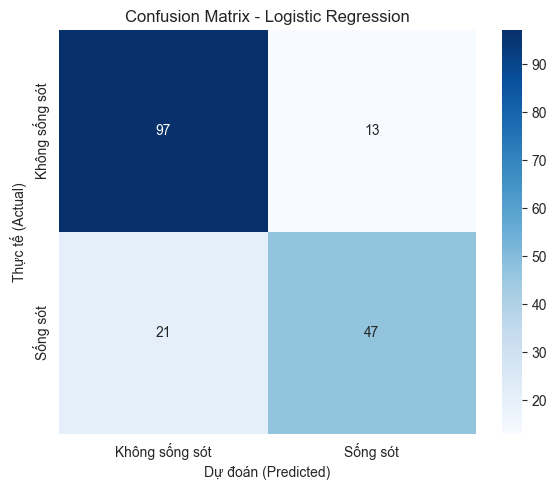

In [14]:
cm_log = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Không sống sót", "Sống sót"],
            yticklabels=["Không sống sót", "Sống sót"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.tight_layout()
plt.show()

**Nhận xét:** Mô hình dự đoán tốt hơn ở lớp "Không sống sót" (recall cao hơn) so với lớp "Sống sót" — dễ hiểu vì lớp "Không sống sót" chiếm đa số trong dữ liệu train (~62%), nên mô hình có nhiều ví dụ hơn để học pattern của lớp này.

## 7. So sánh với Linear Regression

Linear Regression **không phải mô hình phân loại** — nó dự đoán một giá trị liên tục, không giới hạn trong [0, 1]. Để so sánh công bằng với bài toán phân loại "sống sót hay không", ta:

1. Train Linear Regression để dự đoán `survived` như một biến số liên tục (0 hoặc 1).
2. Đánh giá bằng chỉ số hồi quy chuẩn (MSE, R²) — đây là cách đánh giá **đúng bản chất** của Linear Regression.
3. Threshold kết quả ở 0.5 để chuyển về nhãn nhị phân, rồi tính Accuracy/Precision/Recall/F1 — để so sánh **trực tiếp** với Logistic Regression như đề bài yêu cầu.

In [15]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred_linreg_raw = linreg.predict(X_test_scaled)

print("Giá trị dự đoán thô của Linear Regression:")
print("  Min :", round(y_pred_linreg_raw.min(), 4))
print("  Max :", round(y_pred_linreg_raw.max(), 4))
print()
print("Lưu ý: giá trị dự đoán VƯỢT RA NGOÀI khoảng [0, 1] hợp lệ của xác suất —")
print("đây là hạn chế cố hữu của Linear Regression khi áp dụng cho bài toán phân loại.")

Giá trị dự đoán thô của Linear Regression:
  Min : -0.1769
  Max : 1.0519

Lưu ý: giá trị dự đoán VƯỢT RA NGOÀI khoảng [0, 1] hợp lệ của xác suất —
đây là hạn chế cố hữu của Linear Regression khi áp dụng cho bài toán phân loại.


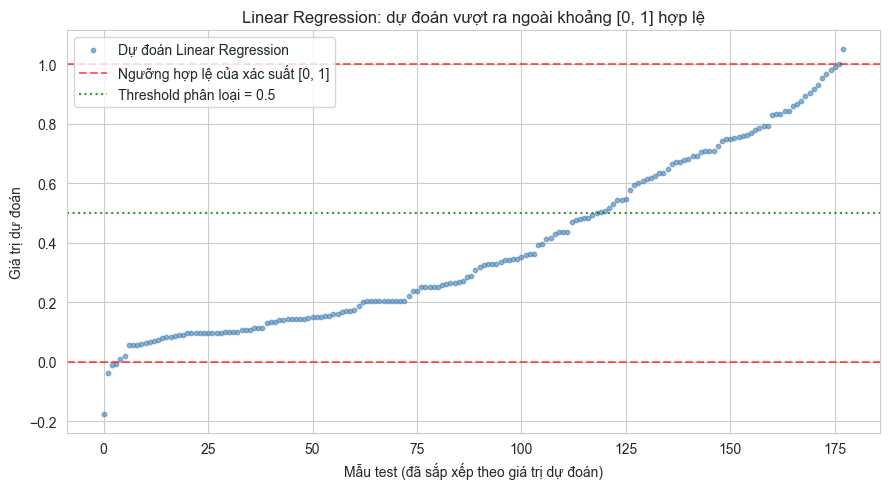

In [16]:
plt.figure(figsize=(9, 5))
sorted_preds = np.sort(y_pred_linreg_raw)
plt.scatter(range(len(sorted_preds)), sorted_preds, s=10, alpha=0.6, color="steelblue", label="Dự đoán Linear Regression")
plt.axhline(0, color="red", linestyle="--", alpha=0.6, label="Ngưỡng hợp lệ của xác suất [0, 1]")
plt.axhline(1, color="red", linestyle="--", alpha=0.6)
plt.axhline(0.5, color="green", linestyle=":", alpha=0.8, label="Threshold phân loại = 0.5")
plt.xlabel("Mẫu test (đã sắp xếp theo giá trị dự đoán)")
plt.ylabel("Giá trị dự đoán")
plt.title("Linear Regression: dự đoán vượt ra ngoài khoảng [0, 1] hợp lệ")
plt.legend()
plt.tight_layout()
plt.show()

**Nhận xét:** Biểu đồ trên minh họa rõ vấn đề lý thuyết cốt lõi — một số dự đoán của Linear Regression **âm** (dưới 0) hoặc **lớn hơn 1**, những giá trị này **vô nghĩa** khi diễn giải như xác suất sống sót. Logistic Regression giải quyết triệt để vấn đề này nhờ hàm sigmoid, luôn đảm bảo output nằm trong [0, 1].

### 7.1. Đánh giá Linear Regression theo đúng bản chất hồi quy (MSE, R²)

In [23]:
mse_linreg = mean_squared_error(y_test, y_pred_linreg_raw)
r2_linreg = r2_score(y_test, y_pred_linreg_raw)

print("=== Linear Regression - Đánh giá hồi quy ===")
print(f"MSE : {mse_linreg:.4f}")
print(f"R²  : {r2_linreg:.4f}")
print()
print(f"R² = {r2_linreg:.4f} nghĩa là mô hình chỉ giải thích được khoảng {r2_linreg*100:.1f}% biến thiên của target —")
print("khá thấp, phản ánh việc Linear Regression không phù hợp về bản chất với biến target nhị phân (0/1).")

=== Linear Regression - Đánh giá hồi quy ===
MSE : 0.1444
R²  : 0.3882

R² = 0.3882 nghĩa là mô hình chỉ giải thích được khoảng 38.8% biến thiên của target —
khá thấp, phản ánh việc Linear Regression không phù hợp về bản chất với biến target nhị phân (0/1).


### 7.2. Threshold ở 0.5 để so sánh trực tiếp với Logistic Regression (Accuracy, Precision, Recall, F1)

In [18]:
y_pred_linreg_binary = (y_pred_linreg_raw >= 0.5).astype(int)

acc_lin = accuracy_score(y_test, y_pred_linreg_binary)
prec_lin = precision_score(y_test, y_pred_linreg_binary)
rec_lin = recall_score(y_test, y_pred_linreg_binary)
f1_lin = f1_score(y_test, y_pred_linreg_binary)

print("=== Linear Regression (sau khi threshold 0.5) - Kết quả trên tập test ===")
print(f"Accuracy  : {acc_lin:.4f}")
print(f"Precision : {prec_lin:.4f}")
print(f"Recall    : {rec_lin:.4f}")
print(f"F1-score  : {f1_lin:.4f}")
print()
print(classification_report(y_test, y_pred_linreg_binary, target_names=["Không sống sót", "Sống sót"]))

=== Linear Regression (sau khi threshold 0.5) - Kết quả trên tập test ===
Accuracy  : 0.8090
Precision : 0.7833
Recall    : 0.6912
F1-score  : 0.7344

                precision    recall  f1-score   support

Không sống sót       0.82      0.88      0.85       110
      Sống sót       0.78      0.69      0.73        68

      accuracy                           0.81       178
     macro avg       0.80      0.79      0.79       178
  weighted avg       0.81      0.81      0.81       178



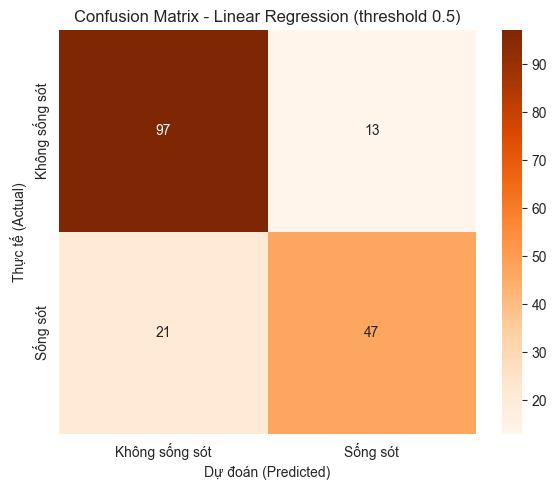

In [19]:
cm_lin = confusion_matrix(y_test, y_pred_linreg_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lin, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Không sống sót", "Sống sót"],
            yticklabels=["Không sống sót", "Sống sót"])
plt.title("Confusion Matrix - Linear Regression (threshold 0.5)")
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.tight_layout()
plt.show()

## 8. So sánh tổng hợp Logistic Regression vs Linear Regression

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Linear Regression (threshold 0.5)"],
    "Accuracy": [acc_log, acc_lin],
    "Precision": [prec_log, prec_lin],
    "Recall": [rec_log, rec_lin],
    "F1-score": [f1_log, f1_lin],
})

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.809,0.7833,0.6912,0.7344
1,Linear Regression (threshold 0.5),0.809,0.7833,0.6912,0.7344


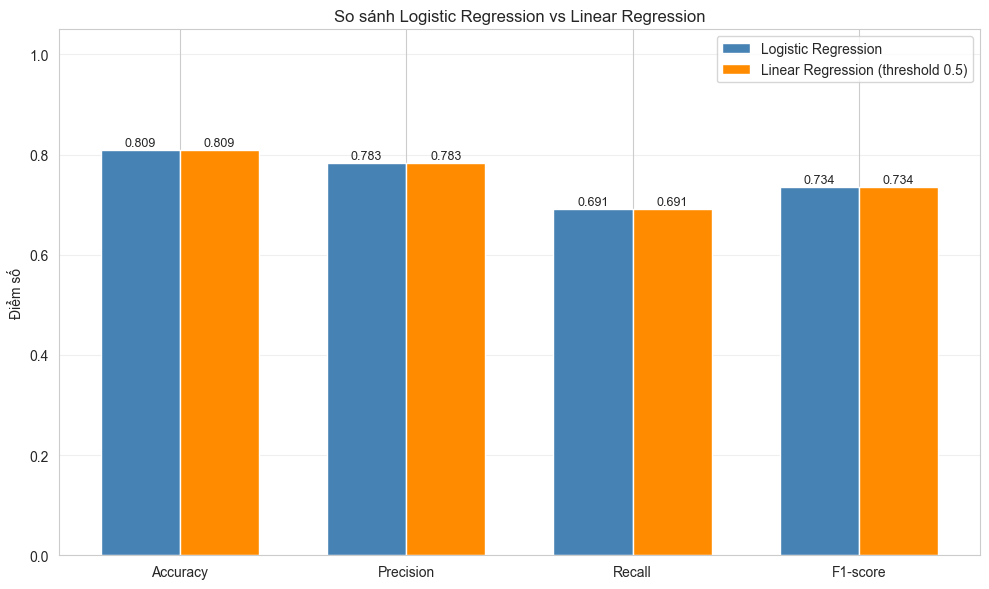

In [21]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars_log = ax.bar(x - width/2, comparison_df.loc[0, metrics], width, label="Logistic Regression", color="steelblue")
bars_lin = ax.bar(x + width/2, comparison_df.loc[1, metrics], width, label="Linear Regression (threshold 0.5)", color="darkorange")

ax.set_ylabel("Điểm số")
ax.set_title("So sánh Logistic Regression vs Linear Regression")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in [bars_log, bars_lin]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Nhận xét tổng kết

- **Về các chỉ số phân loại (sau khi threshold Linear Regression ở 0.5):** Hai mô hình cho kết quả **rất gần nhau**, thậm chí trùng nhau ở tập test này. Điều này không có nghĩa Linear Regression "ngang hàng" với Logistic Regression về mặt lý thuyết — chỉ đơn giản là với tập test tương đối nhỏ và ranh giới quyết định giữa 2 mô hình khá gần nhau trong bài toán cụ thể này, việc threshold ở 0.5 vô tình cho ra cùng một tập nhãn dự đoán.
- **Về bản chất lý thuyết, Logistic Regression phù hợp hơn hẳn cho bài toán phân loại nhị phân**, vì các lý do:
  1. **Output có ý nghĩa xác suất:** Logistic Regression dùng hàm sigmoid nên output luôn nằm trong [0, 1], diễn giải được trực tiếp như "xác suất sống sót". Linear Regression thì không — như biểu đồ ở Mục 7 cho thấy, có dự đoán âm hoặc lớn hơn 1, hoàn toàn vô nghĩa khi hiểu là xác suất.
  2. **Hàm mất mát phù hợp:** Logistic Regression tối ưu hóa *log-loss* (cross-entropy), được thiết kế riêng cho phân loại. Linear Regression tối ưu hóa MSE, vốn dành cho bài toán hồi quy, không phạt đúng cách các dự đoán sai lớp.
  3. **R² thấp (~0.39) của Linear Regression** ở Mục 7.1 phản ánh đúng thực tế: dùng thước đo hồi quy để đánh giá một biến nhị phân vốn không phù hợp về bản chất.
- **Kết luận:** Mặc dù các chỉ số phân loại sau threshold khá tương đồng trong trường hợp cụ thể này, **Logistic Regression vẫn là lựa chọn đúng đắn và nên dùng cho bài toán dự đoán sống sót** — vì nó được thiết kế đúng bản chất cho phân loại nhị phân, cho ra xác suất diễn giải được, và không gặp vấn đề dự đoán ra ngoài khoảng hợp lệ như Linear Regression.